# Mental Health Text Dataset — Statistical Analysis

Analysis of social-media posts annotated with mental-health tags.

**Configuration** — change `DATASET_FILENAME` below to point to a different CSV file.
All generated plots are saved into the `artifacts/` directory.

In [ ]:
# ============================================================
# CONFIGURATION — change these values to analyze another dataset
# ============================================================
DATASET_FILENAME = 'data.csv'   # path to the CSV file
CSV_SEP = ';'                    # CSV separator
CSV_ENCODING = 'utf-8'
TEXT_COL = 'text'
TAG_COL = 'tag'
ARTIFACTS_DIR = 'artifacts'      # folder where all plots will be saved

# Whether to downsample the majority class for visualization purposes
DOWNSAMPLE_MAJORITY = True
MAJORITY_CAP_MULTIPLIER = 3      # cap majority class at N x second-largest class
RANDOM_STATE = 42

In [2]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Make sure the artifacts directory exists
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# Stem (filename without extension) used to prefix artifact filenames so that
# running this notebook on different datasets does not overwrite each other's outputs.
DATASET_STEM = os.path.splitext(os.path.basename(DATASET_FILENAME))[0]

def artifact_path(name: str) -> str:
    """Build a path inside the artifacts directory, prefixed with the dataset stem."""
    return os.path.join(ARTIFACTS_DIR, f'{DATASET_STEM}__{name}')

print(f'Dataset:   {DATASET_FILENAME}')
print(f'Artifacts: {os.path.abspath(ARTIFACTS_DIR)}')

Dataset:   data_filtered.csv
Artifacts: /Users/ilyasar004/Documents/nlp/project/artifacts


---
## 1. Load Data

In [3]:
df = pd.read_csv(DATASET_FILENAME, sep=CSV_SEP, encoding=CSV_ENCODING)
df = df[[TEXT_COL, TAG_COL]].copy()
df = df.dropna().reset_index(drop=True)

print(f'Shape (raw): {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print()
print('Raw tag distribution:')
print(df[TAG_COL].value_counts().to_string())

if DOWNSAMPLE_MAJORITY and df[TAG_COL].nunique() > 1:
    counts = df[TAG_COL].value_counts()
    second_largest = counts.iloc[1]
    cap = second_largest * MAJORITY_CAP_MULTIPLIER
    majority_class = counts.index[0]
    if counts.iloc[0] > cap:
        df_majority = df[df[TAG_COL] == majority_class].sample(n=cap, random_state=RANDOM_STATE)
        df_rest = df[df[TAG_COL] != majority_class]
        df = pd.concat([df_majority, df_rest]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
        print(f'\nAfter downsampling "{majority_class}" to {cap} samples:')
        print(df[TAG_COL].value_counts().to_string())

print(f'\nFinal shape: {df.shape}')
df.head(3)

Shape (raw): (37024, 2)
Columns: ['text', 'tag']

Raw tag distribution:
tag
депрессия                   19885
тревожное р-во               6803
ОКР                          3310
ПРЛ                          3182
БАР                          1577
тревожное р-во/невроз         969
шизофрения                    942
паранойя                      355
тревожное р-во/депрессия        1

Final shape: (37024, 2)


,text,tag
0,Всем добрый день! У меня БАР 2 типа. Начала ч...,БАР
1,Попробуйте успокоиться. Сделайте выводы. Приго...,БАР
2,вы серьезно? Алкоголизм это к лучшему? Вас с...,БАР


---
## 2. Tag Distribution Statistics

In [4]:
tag_counts = df[TAG_COL].value_counts()
tag_pct = df[TAG_COL].value_counts(normalize=True) * 100

tag_stats = pd.DataFrame({
    'count': tag_counts,
    'percentage': tag_pct.round(2)
})

print('=== Tag Distribution ===')
print(tag_stats.to_string())
print(f'\nTotal samples: {len(df)}')
print(f'Number of unique tags: {df[TAG_COL].nunique()}')

# Save table to artifacts as well
tag_stats.to_csv(artifact_path('tag_distribution.csv'))
print(f'\nSaved table to {artifact_path("tag_distribution.csv")}')

=== Tag Distribution ===
                          count  percentage
tag                                        
депрессия                 19885       53.71
тревожное р-во             6803       18.37
ОКР                        3310        8.94
ПРЛ                        3182        8.59
БАР                        1577        4.26
тревожное р-во/невроз       969        2.62
шизофрения                  942        2.54
паранойя                    355        0.96
тревожное р-во/депрессия      1        0.00

Total samples: 37024
Number of unique tags: 9

Saved table to artifacts/data_filtered__tag_distribution.csv


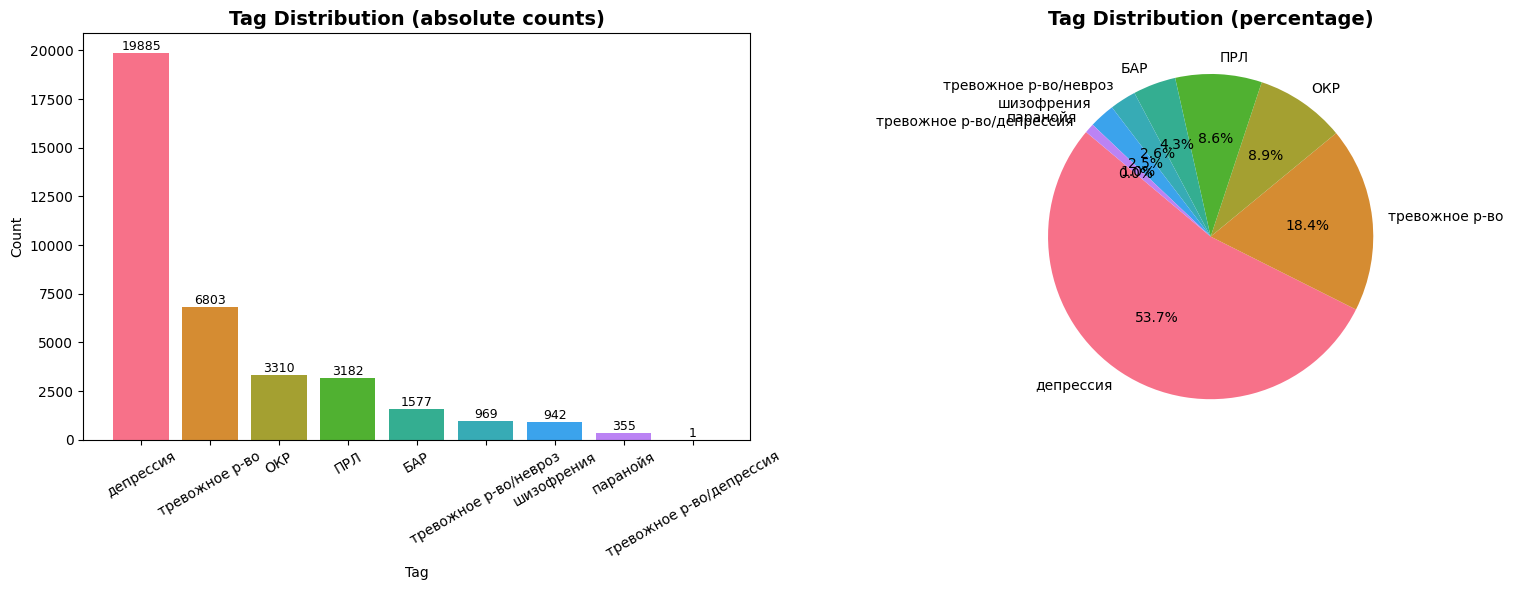

Chart saved to artifacts/data_filtered__tag_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = sns.color_palette('husl', len(tag_counts))
axes[0].bar(tag_counts.index.astype(str), tag_counts.values, color=colors)
axes[0].set_title('Tag Distribution (absolute counts)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tag')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for i, (tag, count) in enumerate(tag_counts.items()):
    axes[0].text(i, count, str(count), ha='center', va='bottom', fontsize=9)

axes[1].pie(
    tag_counts.values,
    labels=tag_counts.index.astype(str),
    autopct='%1.1f%%',
    colors=colors,
    startangle=140
)
axes[1].set_title('Tag Distribution (percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
out = artifact_path('tag_distribution.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved to {out}')

---
## 3. Text Length Statistics

In [6]:
df['text_len'] = df[TEXT_COL].astype(str).apply(len)
df['word_count'] = df[TEXT_COL].astype(str).apply(lambda x: len(x.split()))

print('=== Text Length Statistics (characters) ===')
print(df['text_len'].describe().round(1))

print('\n=== Word Count Statistics ===')
print(df['word_count'].describe().round(1))

=== Text Length Statistics (characters) ===
count    37024.0
mean       392.8
std        625.8
min          6.0
25%        122.0
50%        227.0
75%        436.0
max      32767.0
Name: text_len, dtype: float64

=== Word Count Statistics ===
count    37024.0
mean        61.2
std         97.2
min          1.0
25%         19.0
50%         35.0
75%         68.0
max       5668.0
Name: word_count, dtype: float64


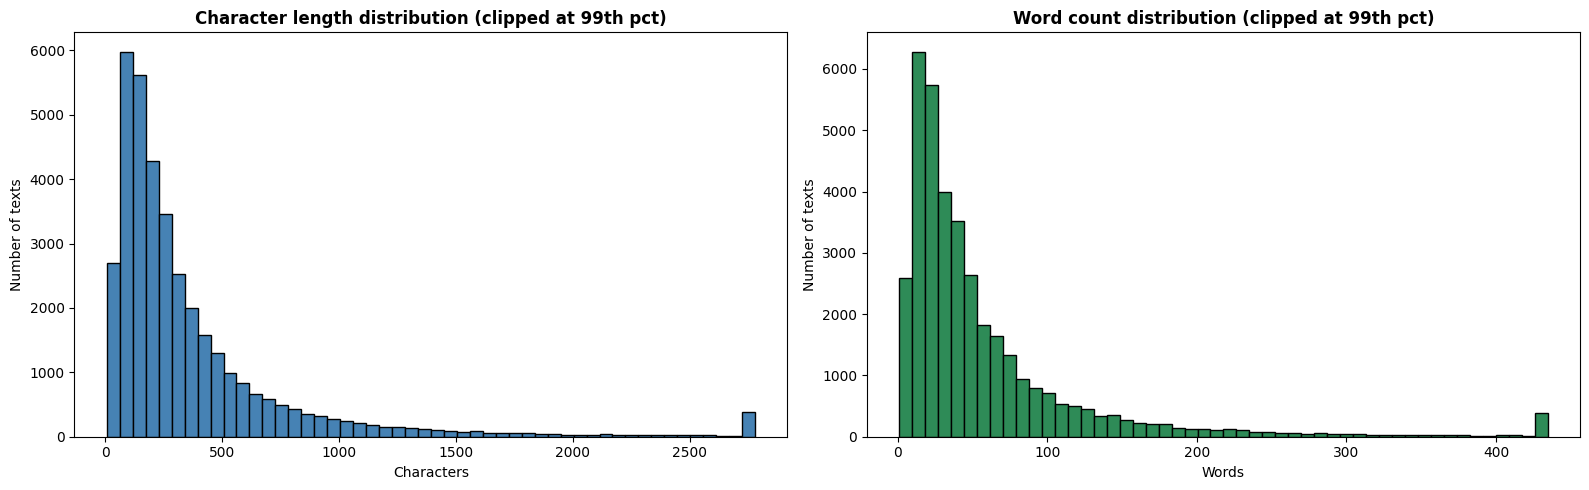

Chart saved to artifacts/data_filtered__text_length_distribution.png


In [7]:
# Histograms of character length and word count
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df['text_len'].clip(upper=df['text_len'].quantile(0.99)),
             bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Character length distribution (clipped at 99th pct)', fontweight='bold')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Number of texts')

axes[1].hist(df['word_count'].clip(upper=df['word_count'].quantile(0.99)),
             bins=50, color='seagreen', edgecolor='black')
axes[1].set_title('Word count distribution (clipped at 99th pct)', fontweight='bold')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Number of texts')

plt.tight_layout()
out = artifact_path('text_length_distribution.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved to {out}')

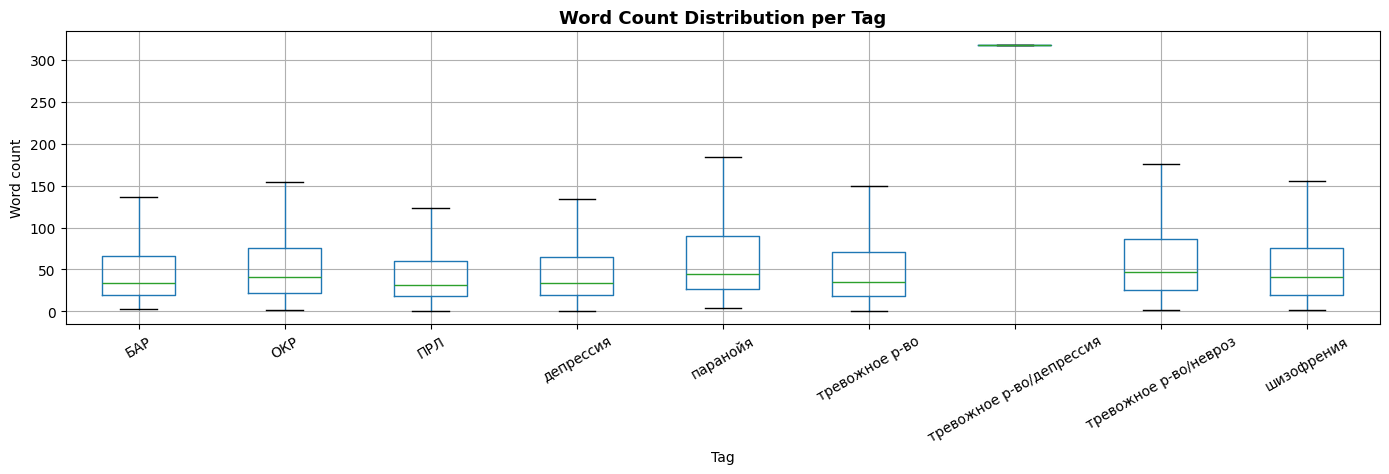

Chart saved to artifacts/data_filtered__word_count_by_tag.png


In [8]:
# Word count distribution per tag (boxplot)
fig, ax = plt.subplots(figsize=(14, 5))
df.boxplot(column='word_count', by=TAG_COL, ax=ax, showfliers=False)
ax.set_title('Word Count Distribution per Tag', fontsize=13, fontweight='bold')
ax.set_xlabel('Tag')
ax.set_ylabel('Word count')
plt.suptitle('')
plt.xticks(rotation=30)
plt.tight_layout()
out = artifact_path('word_count_by_tag.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved to {out}')

In [9]:
# Mean / median text length per tag
per_tag_len = df.groupby(TAG_COL)[['text_len', 'word_count']].agg(['mean', 'median', 'std']).round(1)
print('=== Length statistics per tag ===')
print(per_tag_len.to_string())
per_tag_len.to_csv(artifact_path('length_per_tag.csv'))
print(f'\nSaved table to {artifact_path("length_per_tag.csv")}')

=== Length statistics per tag ===
                         text_len                word_count              
                             mean  median    std       mean median    std
tag                                                                      
БАР                         403.1   223.0  756.7       62.1   34.0  118.6
ОКР                         422.3   262.0  620.5       65.8   41.0   96.5
ПРЛ                         376.7   208.0  696.2       58.4   32.0  100.4
депрессия                   383.3   217.0  632.7       60.0   34.0   99.2
паранойя                    488.7   278.0  669.3       77.9   44.0  109.6
тревожное р-во              386.4   230.0  511.2       59.5   35.0   77.5
тревожное р-во/депрессия   1965.0  1965.0    NaN      318.0  318.0    NaN
тревожное р-во/невроз       507.7   301.0  719.2       80.0   47.0  116.3
шизофрения                  415.6   255.0  618.6       65.6   41.0  101.7

Saved table to artifacts/data_filtered__length_per_tag.csv


---
## 4. Duplicates & Empty Texts

In [10]:
n_total = len(df)
n_dup_text = df[TEXT_COL].duplicated().sum()
n_empty = (df[TEXT_COL].astype(str).str.strip() == '').sum()
n_short = (df['word_count'] < 5).sum()

print(f'Total samples:                   {n_total}')
print(f'Duplicate texts:                 {n_dup_text} ({n_dup_text / n_total * 100:.2f}%)')
print(f'Empty texts:                     {n_empty}')
print(f'Very short texts (< 5 words):    {n_short} ({n_short / n_total * 100:.2f}%)')

Total samples:                   37024
Duplicate texts:                 262 (0.71%)
Empty texts:                     0
Very short texts (< 5 words):    322 (0.87%)


---
## 5. Summary

In [11]:
summary = {
    'dataset_file': DATASET_FILENAME,
    'n_samples': int(len(df)),
    'n_classes': int(df[TAG_COL].nunique()),
    'mean_chars': float(df['text_len'].mean()),
    'median_chars': float(df['text_len'].median()),
    'mean_words': float(df['word_count'].mean()),
    'median_words': float(df['word_count'].median()),
    'duplicate_texts': int(n_dup_text),
    'empty_texts': int(n_empty),
}
summary_df = pd.DataFrame(list(summary.items()), columns=['metric', 'value'])
print('=== Dataset summary ===')
print(summary_df.to_string(index=False))
summary_df.to_csv(artifact_path('summary.csv'), index=False)
print(f'\nSaved to {artifact_path("summary.csv")}')

=== Dataset summary ===
         metric             value
   dataset_file data_filtered.csv
      n_samples             37024
      n_classes                 9
     mean_chars         392.75948
   median_chars             227.0
     mean_words         61.226448
   median_words              35.0
duplicate_texts               262
    empty_texts                 0

Saved to artifacts/data_filtered__summary.csv
